In [2]:
from pathlib import Path
import pandas as pd
import json

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

SKILLCORNER_DATA = PROJECT_ROOT / "external" / "skillcorner-opendata" / "data"

print(SKILLCORNER_DATA)
print(SKILLCORNER_DATA.exists())


c:\Users\amsch\. Personal Work\Projects\Soccer TIPS\external\skillcorner-opendata\data
True


In [3]:
matches_path = SKILLCORNER_DATA / "matches.json"

with open(matches_path, "r", encoding="utf-8") as f:
    matches = json.load(f)

type(matches), len(matches)

(list, 10)

In [4]:
matches_df = pd.DataFrame(matches)
matches_df.head()

,id,date_time,home_team,away_team,status,competition_id,season_id,competition_edition_id
0,2017461,2025-05-17T09:35:00Z,"{'id': 868, 'short_name': 'Melbourne V FC'}","{'id': 4177, 'short_name': 'Auckland FC'}",closed,61,95,870
1,2015213,2025-05-03T08:00:00Z,"{'id': 1803, 'short_name': 'Western United'}","{'id': 4177, 'short_name': 'Auckland FC'}",closed,61,95,870
2,2013725,2025-04-27T07:00:00Z,"{'id': 1803, 'short_name': 'Western United'}","{'id': 869, 'short_name': 'Sydney FC'}",closed,61,95,870
3,2011166,2025-04-12T05:00:00Z,"{'id': 867, 'short_name': 'Wellington P FC'}","{'id': 868, 'short_name': 'Melbourne V FC'}",closed,61,95,870
4,2006229,2025-03-07T08:35:00Z,"{'id': 2380, 'short_name': 'Melbourne City'}","{'id': 1804, 'short_name': 'Macarthur FC'}",closed,61,95,870


In [5]:
matches_df['home_team_name'] = matches_df['home_team'].apply(lambda x: x['short_name'])
matches_df['away_team_name'] = matches_df['away_team'].apply(lambda x: x['short_name'])

matches_df[['id', 'home_team_name', 'away_team_name']].head()

,id,home_team_name,away_team_name
0,2017461,Melbourne V FC,Auckland FC
1,2015213,Western United,Auckland FC
2,2013725,Western United,Sydney FC
3,2011166,Wellington P FC,Melbourne V FC
4,2006229,Melbourne City,Macarthur FC


In [6]:
match_id = matches_df.iloc[0]['id']   # picks first match

match_folder = SKILLCORNER_DATA / "matches" / str(match_id)

print(match_folder)

c:\Users\amsch\. Personal Work\Projects\Soccer TIPS\external\skillcorner-opendata\data\matches\2017461


In [7]:
import os

os.listdir(match_folder)

['2017461_dynamic_events.csv',
 '2017461_match.json',
 '2017461_phases_of_play.csv',
 '2017461_tracking_extrapolated.jsonl']

In [8]:
match_file = match_folder / f"{match_id}_match.json"

with open(match_file, "r", encoding="utf-8") as f:
    match_data = json.load(f)

type(match_data)

dict

In [9]:
match_data.keys()

dict_keys(['id', 'home_team_score', 'away_team_score', 'date_time', 'stadium', 'home_team', 'home_team_kit', 'away_team', 'away_team_kit', 'home_team_coach', 'away_team_coach', 'home_team_playing_time', 'away_team_playing_time', 'competition_edition', 'match_periods', 'competition_round', 'referees', 'players', 'status', 'home_team_side', 'ball', 'pitch_length', 'pitch_width'])

In [10]:
match_data

{'id': 2017461,
 'home_team_score': 0,
 'away_team_score': 1,
 'date_time': '2025-05-17T09:35:00Z',
 'stadium': {'id': 1480,
  'name': 'Melbourne Rectangular Stadium',
  'city': 'Melbourne',
  'capacity': 30050},
 'home_team': {'id': 868,
  'name': 'Melbourne Victory Football Club',
  'short_name': 'Melbourne V FC',
  'acronym': 'MEL'},
 'home_team_kit': {'id': 17096,
  'team_id': 868,
  'season': {'id': 95,
   'start_year': 2024,
   'end_year': 2025,
   'name': '2024/2025'},
  'name': 'Home',
  'jersey_color': '#001536',
  'number_color': '#FFFFFF'},
 'away_team': {'id': 4177,
  'name': 'Auckland FC',
  'short_name': 'Auckland FC',
  'acronym': 'AUC'},
 'away_team_kit': {'id': 14075,
  'team_id': 4177,
  'season': {'id': 95,
   'start_year': 2024,
   'end_year': 2025,
   'name': '2024/2025'},
  'name': 'away',
  'jersey_color': '#ffffff',
  'number_color': '#000000'},
 'home_team_coach': None,
 'away_team_coach': None,
 'home_team_playing_time': {'minutes_tip': 29.27, 'minutes_otip': 

In [11]:
players = match_data["players"]

type(players), len(players)

(list, 36)

In [12]:
players[0]

{'player_role': {'id': 13,
  'position_group': 'Wide Attacker',
  'name': 'Right Winger',
  'acronym': 'RW'},
 'start_time': '01:23:12',
 'end_time': None,
 'number': 23,
 'yellow_card': 0,
 'red_card': 0,
 'injured': False,
 'goal': 0,
 'own_goal': 0,
 'playing_time': {'total': {'minutes_tip': 4.3,
   'minutes_otip': 2.41,
   'start_frame': 62590,
   'end_frame': 70419,
   'minutes_played': 13.05,
   'minutes_played_regular_time': 13.05},
  'by_period': [{'name': 'period_2',
    'minutes_tip': 4.3,
    'minutes_otip': 2.41,
    'start_frame': 62590,
    'end_frame': 70419,
    'minutes_played': 13.05}]},
 'team_player_id': 1564070,
 'team_id': 868,
 'id': 795521,
 'first_name': 'Alexander',
 'last_name': 'Badolato',
 'short_name': 'A. Badolato',
 'birthday': '2005-02-23',
 'trackable_object': 797084,
 'gender': 'male'}

In [13]:
players_df = pd.DataFrame(players)

players_df.head()

,player_role,start_time,end_time,number,yellow_card,red_card,injured,goal,own_goal,playing_time,team_player_id,team_id,id,first_name,last_name,short_name,birthday,trackable_object,gender
0,"{'id': 13, 'position_group': 'Wide Attacker', ...",01:23:12,NaN,23,0,0,False,0,0,"{'total': {'minutes_tip': 4.3, 'minutes_otip':...",1564070,868,795521,Alexander,Badolato,A. Badolato,2005-02-23,797084,male
1,"{'id': 12, 'position_group': 'Wide Attacker', ...",01:02:21,NaN,14,0,0,False,0,0,"{'total': {'minutes_tip': 5.86, 'minutes_otip'...",1507975,4177,965685,Liam,Gillion,L. Gillion,2002-10-17,967248,male
2,"{'id': 2, 'position_group': 'Central Defender'...",01:14:54,NaN,5,0,0,False,0,0,"{'total': {'minutes_tip': 3.22, 'minutes_otip'...",1507955,4177,31147,Tommy,Smith,T. Smith,1990-03-31,32245,male
3,"{'id': 12, 'position_group': 'Wide Attacker', ...",00:00:00,01:23:12,17,0,0,False,0,0,"{'total': {'minutes_tip': 24.97, 'minutes_otip...",72948,868,50955,Nishan,Velupillay,N. Velupillay,2001-05-07,52081,male
4,"{'id': 9, 'position_group': 'Midfield', 'name'...",00:00:00,01:19:39,28,0,0,False,0,0,"{'total': {'minutes_tip': 15.27, 'minutes_otip...",1507957,4177,23418,Luis Felipe,Gallegos Leiva,F. Gallegos,1991-12-03,24342,male


In [14]:
players_df.columns

Index(['player_role', 'start_time', 'end_time', 'number', 'yellow_card',
       'red_card', 'injured', 'goal', 'own_goal', 'playing_time',
       'team_player_id', 'team_id', 'id', 'first_name', 'last_name',
       'short_name', 'birthday', 'trackable_object', 'gender'],
      dtype='str')

In [15]:
match_summary = {
    "match_id": match_data["id"],
    "home_team": match_data["home_team"]["short_name"],
    "away_team": match_data["away_team"]["short_name"],
    "score": f'{match_data["home_team_score"]}-{match_data["away_team_score"]}',
    "pitch_length": match_data["pitch_length"],
    "pitch_width": match_data["pitch_width"],
    "home_team_side": match_data["home_team_side"],
    "ball_trackable_object": match_data["ball"]["trackable_object"]
}

match_summary

{'match_id': 2017461,
 'home_team': 'Melbourne V FC',
 'away_team': 'Auckland FC',
 'score': '0-1',
 'pitch_length': 105,
 'pitch_width': 68,
 'home_team_side': ['left_to_right', 'right_to_left'],
 'ball_trackable_object': 55}

In [16]:
players_df[['short_name', 'team_id', 'trackable_object']].head()

,short_name,team_id,trackable_object
0,A. Badolato,868,797084
1,L. Gillion,4177,967248
2,T. Smith,4177,32245
3,N. Velupillay,868,52081
4,F. Gallegos,4177,24342


In [17]:
players_df['team_id'].value_counts()

team_id
868     18
4177    18
Name: count, dtype: int64

In [18]:
tracking_file = match_folder / f"{match_id}_tracking_extrapolated.jsonl"

tracking_file

WindowsPath('c:/Users/amsch/. Personal Work/Projects/Soccer TIPS/external/skillcorner-opendata/data/matches/2017461/2017461_tracking_extrapolated.jsonl')

In [19]:
import json

with open(tracking_file, "r", encoding="utf-8") as f:
    first_frame = json.loads(f.readline())

first_frame

{'frame': 0,
 'timestamp': None,
 'period': None,
 'ball_data': {'x': None, 'y': None, 'z': None, 'is_detected': None},
 'possession': {'player_id': None, 'group': None},
 'image_corners_projection': {'x_top_left': None,
  'y_top_left': None,
  'x_bottom_left': None,
  'y_bottom_left': None,
  'x_bottom_right': None,
  'y_bottom_right': None,
  'x_top_right': None,
  'y_top_right': None},
 'player_data': []}

In [20]:
usable_frame = None

with open(tracking_file, "r", encoding="utf-8") as f:
    for line in f:
        frame = json.loads(line)

        if frame["timestamp"] is not None and len(frame["player_data"]) > 0:
            usable_frame = frame
            break

usable_frame

{'frame': 2510,
 'timestamp': '00:00:00.00',
 'period': 1,
 'ball_data': {'x': -0.46, 'y': -0.12, 'z': 0.14, 'is_detected': True},
 'possession': {'player_id': None, 'group': None},
 'image_corners_projection': {'x_top_left': -52.76,
  'y_top_left': 39.0,
  'x_bottom_left': -11.0,
  'y_bottom_left': -34.89,
  'x_bottom_right': 11.16,
  'y_bottom_right': -33.61,
  'x_top_right': 40.48,
  'y_top_right': 39.0},
 'player_data': [{'x': -38.16,
   'y': 1.51,
   'player_id': 51678,
   'is_detected': False},
  {'x': -20.78, 'y': 3.31, 'player_id': 51013, 'is_detected': True},
  {'x': -20.93, 'y': 14.81, 'player_id': 51685, 'is_detected': True},
  {'x': -21.03, 'y': -8.49, 'player_id': 800322, 'is_detected': True},
  {'x': -8.6, 'y': 23.72, 'player_id': 811820, 'is_detected': True},
  {'x': -6.26, 'y': 7.29, 'player_id': 159688, 'is_detected': True},
  {'x': -6.21, 'y': -6.49, 'player_id': 157294, 'is_detected': True},
  {'x': 1.14, 'y': 16.43, 'player_id': 11117, 'is_detected': False},
  {'x':

In [21]:
usable_frame.keys()

dict_keys(['frame', 'timestamp', 'period', 'ball_data', 'possession', 'image_corners_projection', 'player_data'])

In [22]:
usable_frame["player_data"][:3]

[{'x': -38.16, 'y': 1.51, 'player_id': 51678, 'is_detected': False},
 {'x': -20.78, 'y': 3.31, 'player_id': 51013, 'is_detected': True},
 {'x': -20.93, 'y': 14.81, 'player_id': 51685, 'is_detected': True}]

In [23]:
frame_players = pd.DataFrame(usable_frame["player_data"])

frame_players.head()

,x,y,player_id,is_detected
0,-38.16,1.51,51678,False
1,-20.78,3.31,51013,True
2,-20.93,14.81,51685,True
3,-21.03,-8.49,800322,True
4,-8.60,23.72,811820,True


In [24]:
frame_players["player_id"].isin(players_df["trackable_object"]).value_counts()

player_id
False    22
Name: count, dtype: int64

In [25]:
frame_player_ids = frame_players["player_id"]

print("Matches players_df['id']:")
print(frame_player_ids.isin(players_df["id"]).value_counts())

print("\nMatches players_df['team_player_id']:")
print(frame_player_ids.isin(players_df["team_player_id"]).value_counts())

print("\nMatches players_df['trackable_object']:")
print(frame_player_ids.isin(players_df["trackable_object"]).value_counts())

Matches players_df['id']:
player_id
True    22
Name: count, dtype: int64

Matches players_df['team_player_id']:
player_id
False    22
Name: count, dtype: int64

Matches players_df['trackable_object']:
player_id
False    22
Name: count, dtype: int64


In [27]:
merged_frame = frame_players.merge(
    players_df,
    left_on="player_id",
    right_on="id",
    how="left"
)

display(
    merged_frame[
        [
            "player_id",
            "short_name",
            "team_id",
            "player_role",
            "x",
            "y",
            "is_detected"
        ]
    ]
)

,player_id,short_name,team_id,player_role,x,y,is_detected
0,51678,J. Duncan,868,"{'id': 0, 'position_group': 'Other', 'name': '...",-38.16,1.51,False
1,51013,B. Hamill,868,"{'id': 4, 'position_group': 'Central Defender'...",-20.78,3.31,True
2,51685,L. Jackson,868,"{'id': 3, 'position_group': 'Central Defender'...",-20.93,14.81,True
3,800322,J. Inserra,868,"{'id': 20, 'position_group': 'Full Back', 'nam...",-21.03,-8.49,True
4,811820,K. Bos,868,"{'id': 19, 'position_group': 'Full Back', 'nam...",-8.60,23.72,True
5,159688,J. Valadon,868,"{'id': 21, 'position_group': 'Midfield', 'name...",-6.26,7.29,True
6,157294,R. Teague,868,"{'id': 22, 'position_group': 'Midfield', 'name...",-6.21,-6.49,True
7,11117,Z. Machach,868,"{'id': 11, 'position_group': 'Midfield', 'name...",1.14,16.43,False
8,11885,D. Arzani,868,"{'id': 13, 'position_group': 'Wide Attacker', ...",0.68,0.69,True
9,50955,N. Velupillay,868,"{'id': 12, 'position_group': 'Wide Attacker', ...",4.59,31.88,True


In [28]:
merged_frame["short_name"].isna().sum()

np.int64(0)

In [29]:
merged_frame["role_name"] = merged_frame["player_role"].apply(lambda x: x["name"])
merged_frame["position_group"] = merged_frame["player_role"].apply(lambda x: x["position_group"])

display(
    merged_frame[
        [
            "short_name",
            "team_id",
            "position_group",
            "role_name",
            "x",
            "y",
            "is_detected"
        ]
    ]
)

,short_name,team_id,position_group,role_name,x,y,is_detected
0,J. Duncan,868,Other,Goalkeeper,-38.16,1.51,False
1,B. Hamill,868,Central Defender,Right Center Back,-20.78,3.31,True
2,L. Jackson,868,Central Defender,Left Center Back,-20.93,14.81,True
3,J. Inserra,868,Full Back,Right Back,-21.03,-8.49,True
4,K. Bos,868,Full Back,Left Back,-8.60,23.72,True
5,J. Valadon,868,Midfield,Left Defensive Midfield,-6.26,7.29,True
6,R. Teague,868,Midfield,Right Defensive Midfield,-6.21,-6.49,True
7,Z. Machach,868,Midfield,Attacking Midfield,1.14,16.43,False
8,D. Arzani,868,Wide Attacker,Right Winger,0.68,0.69,True
9,N. Velupillay,868,Wide Attacker,Left Winger,4.59,31.88,True


In [30]:
merged_frame["team_id"].value_counts()

team_id
868     11
4177    11
Name: count, dtype: int64

In [31]:
merged_frame["is_detected"].value_counts()

is_detected
True     18
False     4
Name: count, dtype: int64

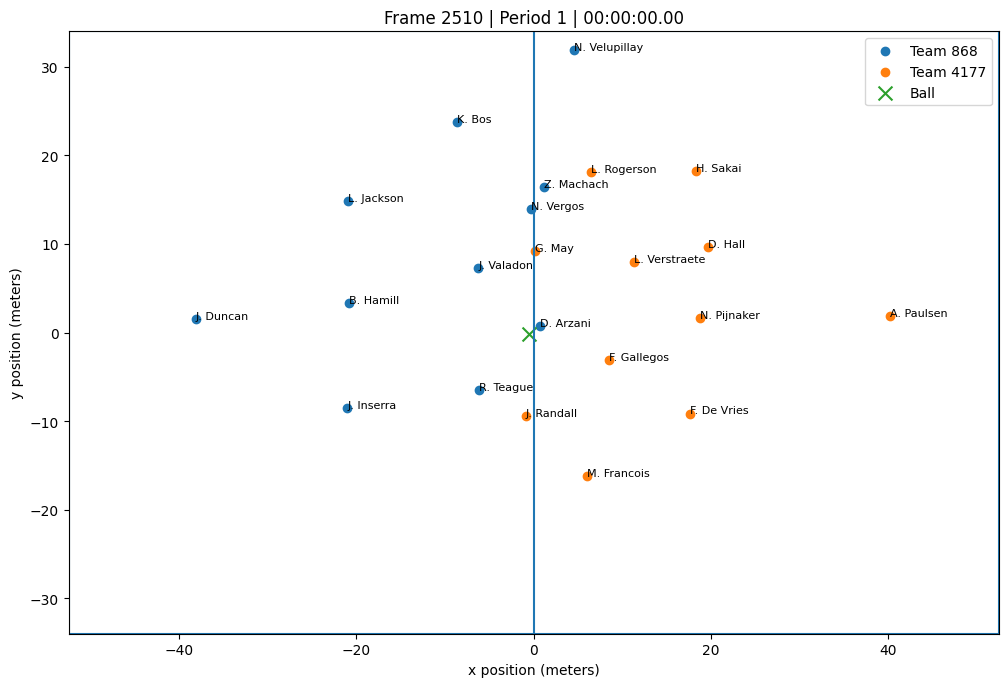

In [32]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 8))

# Pitch boundaries based on 105 x 68 pitch
ax.set_xlim(-52.5, 52.5)
ax.set_ylim(-34, 34)

# Pitch outline
ax.plot([-52.5, 52.5, 52.5, -52.5, -52.5], [-34, -34, 34, 34, -34])

# Halfway line
ax.axvline(0)

# Players by team
for team_id, group in merged_frame.groupby("team_id"):
    ax.scatter(group["x"], group["y"], label=f"Team {team_id}")

    for _, row in group.iterrows():
        ax.text(row["x"], row["y"], row["short_name"], fontsize=8)

# Ball
ball = usable_frame["ball_data"]
ax.scatter(ball["x"], ball["y"], marker="x", s=100, label="Ball")

ax.set_title(f"Frame {usable_frame['frame']} | Period {usable_frame['period']} | {usable_frame['timestamp']}")
ax.set_xlabel("x position (meters)")
ax.set_ylabel("y position (meters)")
ax.legend()
ax.set_aspect("equal")

plt.show()

In [33]:
frame_count = 0
empty_frames = 0
player_counts = []
timestamps_missing = 0
periods = set()
detected_counts = []

with open(tracking_file, "r", encoding="utf-8") as f:
    for line in f:
        frame = json.loads(line)

        frame_count += 1

        if frame["timestamp"] is None:
            timestamps_missing += 1

        if frame["period"] is not None:
            periods.add(frame["period"])

        players = frame["player_data"]

        player_counts.append(len(players))

        if len(players) == 0:
            empty_frames += 1

        detected_counts.append(
            sum(p["is_detected"] for p in players if p["is_detected"] is not None)
        )

summary = {
    "total_frames": frame_count,
    "empty_frames": empty_frames,
    "timestamps_missing": timestamps_missing,
    "periods_found": periods,
    "min_players_in_frame": min(player_counts),
    "max_players_in_frame": max(player_counts),
    "average_players_per_frame": sum(player_counts) / len(player_counts),
    "average_detected_players": sum(detected_counts) / len(detected_counts)
}

summary

{'total_frames': 71451,
 'empty_frames': 31047,
 'timestamps_missing': 12999,
 'periods_found': {1, 2},
 'min_players_in_frame': 0,
 'max_players_in_frame': 22,
 'average_players_per_frame': 12.440525674938069,
 'average_detected_players': 6.364011700326097}

In [34]:
import pandas as pd

player_counts_series = pd.Series(player_counts)

player_counts_series.describe()

count    71451.000000
mean        12.440526
std         10.905345
min          0.000000
25%          0.000000
50%         22.000000
75%         22.000000
max         22.000000
dtype: float64

In [35]:
player_counts_series.value_counts().sort_index()

0     31047
22    40404
Name: count, dtype: int64

In [36]:
expected_files = [
    "{id}_match.json",
    "{id}_tracking_extrapolated.jsonl",
    "{id}_dynamic_events.csv",
    "{id}_phases_of_play.csv"
]

validation_rows = []

for match_id in matches_df["id"]:
    folder = SKILLCORNER_DATA / "matches" / str(match_id)

    row = {
        "match_id": match_id,
        "folder_exists": folder.exists()
    }

    for pattern in expected_files:
        file_name = pattern.format(id=match_id)
        row[file_name.split(f"{match_id}_")[-1]] = (folder / file_name).exists()

    validation_rows.append(row)

file_validation_df = pd.DataFrame(validation_rows)
file_validation_df

,match_id,folder_exists,match.json,tracking_extrapolated.jsonl,dynamic_events.csv,phases_of_play.csv
0,2017461,True,True,True,True,True
1,2015213,True,True,True,True,True
2,2013725,True,True,True,True,True
3,2011166,True,True,True,True,True
4,2006229,True,True,True,True,True
5,1996435,True,True,True,True,True
6,1953632,True,True,True,False,True
7,1925299,True,True,True,True,True
8,1899585,True,True,True,True,True
9,1886347,True,True,True,True,True


In [37]:
file_validation_df.all()

match_id                        True
folder_exists                   True
match.json                      True
tracking_extrapolated.jsonl     True
dynamic_events.csv             False
phases_of_play.csv              True
dtype: bool

In [39]:
match_id = 2017461
match_folder = SKILLCORNER_DATA / "matches" / str(match_id)

print(match_id)
print(match_folder)
print(match_folder.exists())

2017461
c:\Users\amsch\. Personal Work\Projects\Soccer TIPS\external\skillcorner-opendata\data\matches\2017461
True


In [40]:
phases_file = match_folder / f"{match_id}_phases_of_play.csv"

print(phases_file)
print(phases_file.exists())

c:\Users\amsch\. Personal Work\Projects\Soccer TIPS\external\skillcorner-opendata\data\matches\2017461\2017461_phases_of_play.csv
True


In [41]:
phases_df = pd.read_csv(phases_file)

phases_df.head()

,index,match_id,frame_start,frame_end,time_start,time_end,minute_start,second_start,duration,period,...,third_end,penalty_area_end,team_in_possession_width_start,team_in_possession_width_end,team_in_possession_length_start,team_in_possession_length_end,team_out_of_possession_width_start,team_out_of_possession_width_end,team_out_of_possession_length_start,team_out_of_possession_length_end
0,0,2017461,2512,2540,00:00.2,00:03.0,0,0,2.8,1,...,defensive_third,False,40.94,42.11,43.49,53.80,34.80,31.53,41.92,54.89
1,1,2017461,2540,2573,00:03.0,00:06.3,0,3,3.3,1,...,attacking_third,False,42.04,35.13,54.19,64.79,31.55,27.82,55.14,57.02
2,2,2017461,2573,2591,00:06.3,00:08.1,0,6,1.8,1,...,middle_third,False,27.69,23.51,56.97,54.32,34.82,32.71,64.84,63.16
3,3,2017461,2591,2672,00:08.1,00:16.2,0,8,8.1,1,...,attacking_third,True,32.68,29.56,63.32,80.36,23.56,22.04,54.03,26.11
4,4,2017461,2845,2901,00:33.5,00:39.1,0,33,5.6,1,...,middle_third,False,NaN,36.53,NaN,44.17,NaN,41.80,NaN,66.08


In [42]:
phases_df.shape, phases_df.columns

((437, 44),
 Index(['index', 'match_id', 'frame_start', 'frame_end', 'time_start',
        'time_end', 'minute_start', 'second_start', 'duration', 'period',
        'attacking_side_id', 'team_in_possession_id', 'attacking_side',
        'team_in_possession_shortname', 'n_player_possessions_in_phase',
        'team_possession_loss_in_phase', 'team_possession_lead_to_goal',
        'team_possession_lead_to_shot', 'team_in_possession_phase_type',
        'team_in_possession_phase_type_id', 'team_out_of_possession_phase_type',
        'team_out_of_possession_phase_type_id', 'x_start', 'y_start',
        'channel_id_start', 'channel_start', 'third_id_start', 'third_start',
        'penalty_area_start', 'x_end', 'y_end', 'channel_id_end', 'channel_end',
        'third_id_end', 'third_end', 'penalty_area_end',
        'team_in_possession_width_start', 'team_in_possession_width_end',
        'team_in_possession_length_start', 'team_in_possession_length_end',
        'team_out_of_possession_wid

In [43]:
phases_df.isna().sum()

index                                    0
match_id                                 0
frame_start                              0
frame_end                                0
time_start                               0
time_end                                 0
minute_start                             0
second_start                             0
duration                                 0
period                                   0
attacking_side_id                        0
team_in_possession_id                    0
attacking_side                           0
team_in_possession_shortname             0
n_player_possessions_in_phase            0
team_possession_loss_in_phase            0
team_possession_lead_to_goal             0
team_possession_lead_to_shot             0
team_in_possession_phase_type            0
team_in_possession_phase_type_id         0
team_out_of_possession_phase_type        0
team_out_of_possession_phase_type_id     0
x_start                                 23
y_start    

In [44]:
tracking_min_frame = 0
tracking_max_frame = frame_count - 1

phase_frame_check = {
    "min_phase_start": phases_df["frame_start"].min(),
    "max_phase_end": phases_df["frame_end"].max(),
    "tracking_min_frame": tracking_min_frame,
    "tracking_max_frame": tracking_max_frame,
    "phase_start_before_tracking": (phases_df["frame_start"] < tracking_min_frame).sum(),
    "phase_end_after_tracking": (phases_df["frame_end"] > tracking_max_frame).sum(),
    "invalid_phase_ranges": (phases_df["frame_end"] <= phases_df["frame_start"]).sum()
}

phase_frame_check

{'min_phase_start': np.int64(2512),
 'max_phase_end': np.int64(69868),
 'tracking_min_frame': 0,
 'tracking_max_frame': 71450,
 'phase_start_before_tracking': np.int64(0),
 'phase_end_after_tracking': np.int64(0),
 'invalid_phase_ranges': np.int64(0)}

In [45]:
phases_df["team_in_possession_phase_type"].value_counts()

team_in_possession_phase_type
chaotic        143
create         115
finish          64
direct          44
build_up        30
set_play        21
transition      17
quick_break      3
Name: count, dtype: int64

In [46]:
phases_df["team_out_of_possession_phase_type"].value_counts()

team_out_of_possession_phase_type
chaotic                  143
medium_block             115
low_block                 64
defending_direct          44
high_block                30
defending_set_play        21
defending_transition      17
defending_quick_break      3
Name: count, dtype: int64

In [47]:
events_file = match_folder / f"{match_id}_dynamic_events.csv"

events_df = pd.read_csv(events_file)

events_df.head()

C:\Users\amsch\AppData\Local\Temp\ipykernel_9060\1476488348.py:3: DtypeWarning: Columns (0: game_interruption_before, 1: game_interruption_after, 2: first_line_break_type, 3: pressing_chain_end_type) have mixed types. Specify dtype option on import or set low_memory=False.
  events_df = pd.read_csv(events_file)


,event_id,index,match_id,frame_start,frame_end,frame_physical_start,time_start,time_end,minute_start,second_start,...,xloss_player_possession_end,xloss_player_possession_max,xshot_player_possession_start,xshot_player_possession_end,xshot_player_possession_max,is_player_possession_start_matched,is_player_possession_end_matched,is_previous_pass_matched,is_pass_reception_matched,fully_extrapolated
0,8_0,0,2017461,2512,2512,NaN,00:00.2,00:00.2,0,0,...,NaN,NaN,NaN,NaN,NaN,True,True,NaN,True,False
1,1_0,1,2017461,2523,2539,NaN,00:01.3,00:02.9,0,1,...,NaN,NaN,NaN,NaN,NaN,True,True,NaN,NaN,NaN
2,8_1,2,2017461,2526,2540,NaN,00:01.6,00:03.0,0,1,...,NaN,NaN,NaN,NaN,NaN,True,True,True,True,False
3,7_0,3,2017461,2526,2528,NaN,00:01.6,00:01.8,0,1,...,NaN,NaN,NaN,NaN,NaN,True,True,NaN,NaN,False
4,7_1,4,2017461,2526,2540,NaN,00:01.6,00:03.0,0,1,...,NaN,NaN,NaN,NaN,NaN,True,True,NaN,NaN,False


In [48]:
events_df.shape, events_df.columns

((4188, 294),
 Index(['event_id', 'index', 'match_id', 'frame_start', 'frame_end',
        'frame_physical_start', 'time_start', 'time_end', 'minute_start',
        'second_start',
        ...
        'xloss_player_possession_end', 'xloss_player_possession_max',
        'xshot_player_possession_start', 'xshot_player_possession_end',
        'xshot_player_possession_max', 'is_player_possession_start_matched',
        'is_player_possession_end_matched', 'is_previous_pass_matched',
        'is_pass_reception_matched', 'fully_extrapolated'],
       dtype='str', length=294))

In [49]:
events_df.isna().sum().sort_values(ascending=False).head(15)

affected_line_breaking_passing_option_run_subtype_id    4168
affected_line_breaking_passing_option_run_subtype       4168
break_defensive_line                                    4160
push_defensive_line                                     4160
intended_run_behind                                     4160
last_line_break_type_id                                 4139
last_line_break_type                                    4139
pressing_chain_end_type                                 4131
pressing_chain_end_type_id                              4131
affected_line_breaking_passing_option_xthreat           4123
affected_line_breaking_passing_option_attempted         4123
affected_line_break                                     4123
affected_line_breaking_passing_option_dangerous         4123
affected_line_breaking_passing_option_id                4123
affected_line_break_id                                  4123
dtype: int64

In [50]:
event_alignment_check = {
    "event_min_frame": events_df["frame_start"].min(),
    "event_max_frame": events_df["frame_end"].max(),
    "tracking_max_frame": frame_count - 1,
    "events_before_tracking": (events_df["frame_start"] < 0).sum(),
    "events_after_tracking": (events_df["frame_end"] > (frame_count - 1)).sum(),
    "invalid_event_ranges": (events_df["frame_end"] < events_df["frame_start"]).sum()
}

event_alignment_check

{'event_min_frame': np.int64(2512),
 'event_max_frame': np.int64(69858),
 'tracking_max_frame': 71450,
 'events_before_tracking': np.int64(0),
 'events_after_tracking': np.int64(0),
 'invalid_event_ranges': np.int64(0)}

In [51]:
multi_match_summary = []

for match_id in matches_df["id"][:3]:

    folder = SKILLCORNER_DATA / "matches" / str(match_id)

    tracking_file = folder / f"{match_id}_tracking_extrapolated.jsonl"
    phases_file = folder / f"{match_id}_phases_of_play.csv"

    frame_count = 0
    usable_frames = 0

    with open(tracking_file, "r", encoding="utf-8") as f:
        for line in f:
            frame = json.loads(line)

            frame_count += 1

            if len(frame["player_data"]) == 22:
                usable_frames += 1

    phases_df = pd.read_csv(phases_file)

    multi_match_summary.append({
        "match_id": match_id,
        "tracking_frames": frame_count,
        "usable_22_player_frames": usable_frames,
        "phase_rows": len(phases_df)
    })

multi_match_df = pd.DataFrame(multi_match_summary)

multi_match_df

,match_id,tracking_frames,usable_22_player_frames,phase_rows
0,2017461,71451,40404,437
1,2015213,72101,48542,506
2,2013725,70251,44992,486
